Selected 3 random images for verification:
- f_r_616_.jpg
- w_r_45_.jpg
- n_l_27_.jpg
Class mappings loaded successfully.
Example RGB_TO_CLASS_ID: ((0, 0, 0), 0) and ((0, 0, 255), 1)
Visualization function defined.

--- Processing Image 1/3: f_r_616_.jpg ---
  Remapped Class ID Mask shape: (480, 640)
  Unique pixel values in remapped mask_id (should be 0-7): [0 5 6 7]
  Unique RGB colors found in original mask: [[  0   0   0]
 [255   0 255]
 [255 255   0]
 [255 255 255]]


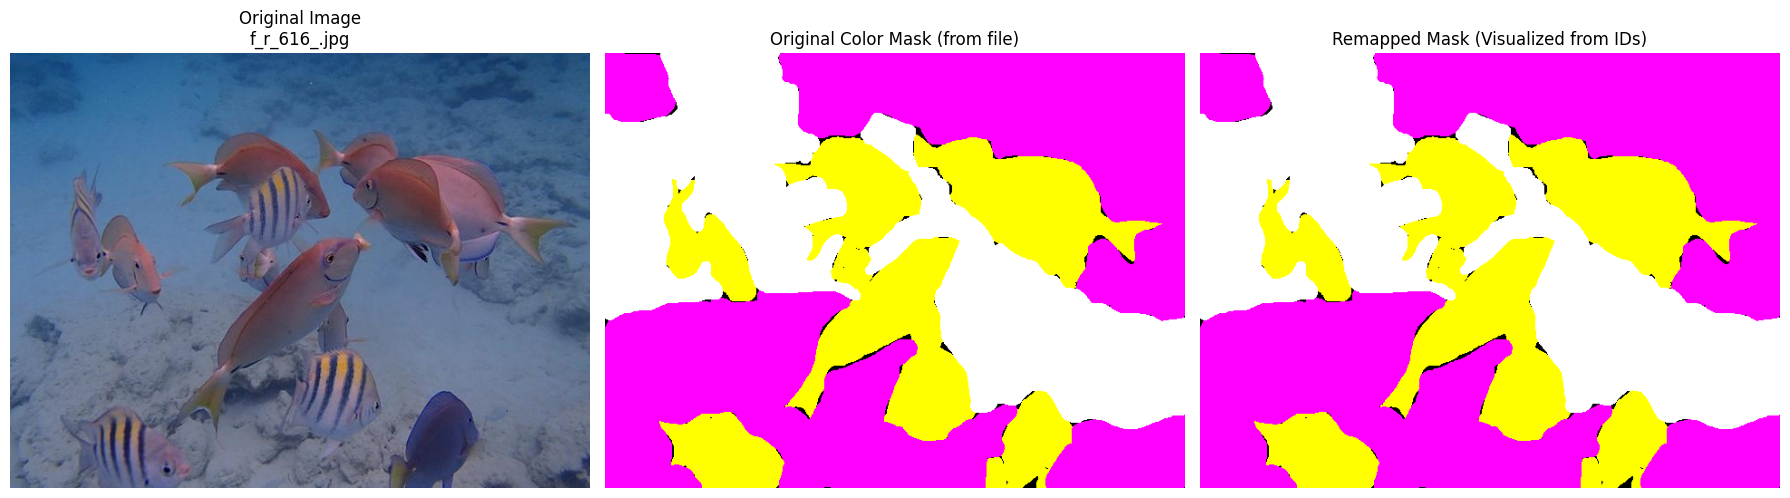


--- Processing Image 2/3: w_r_45_.jpg ---
  Remapped Class ID Mask shape: (480, 640)
  Unique pixel values in remapped mask_id (should be 0-7): [0 1 3]
  Unique RGB colors found in original mask: [[  0   0   0]
 [  0   0 255]
 [  0 255 255]]


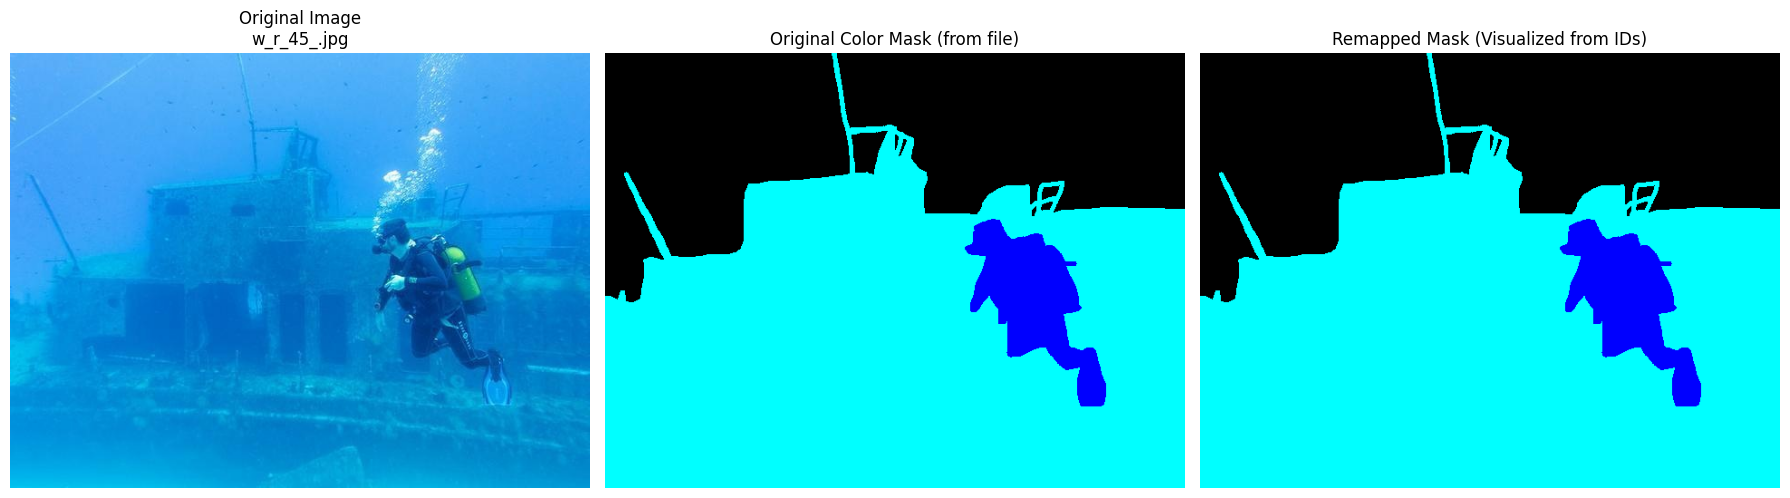


--- Processing Image 3/3: n_l_27_.jpg ---
  Remapped Class ID Mask shape: (540, 960)
  Unique pixel values in remapped mask_id (should be 0-7): [0 1 4 7]
  Unique RGB colors found in original mask: [[  0   0   0]
 [  0   0 255]
 [255   0   0]
 [255 255 255]]


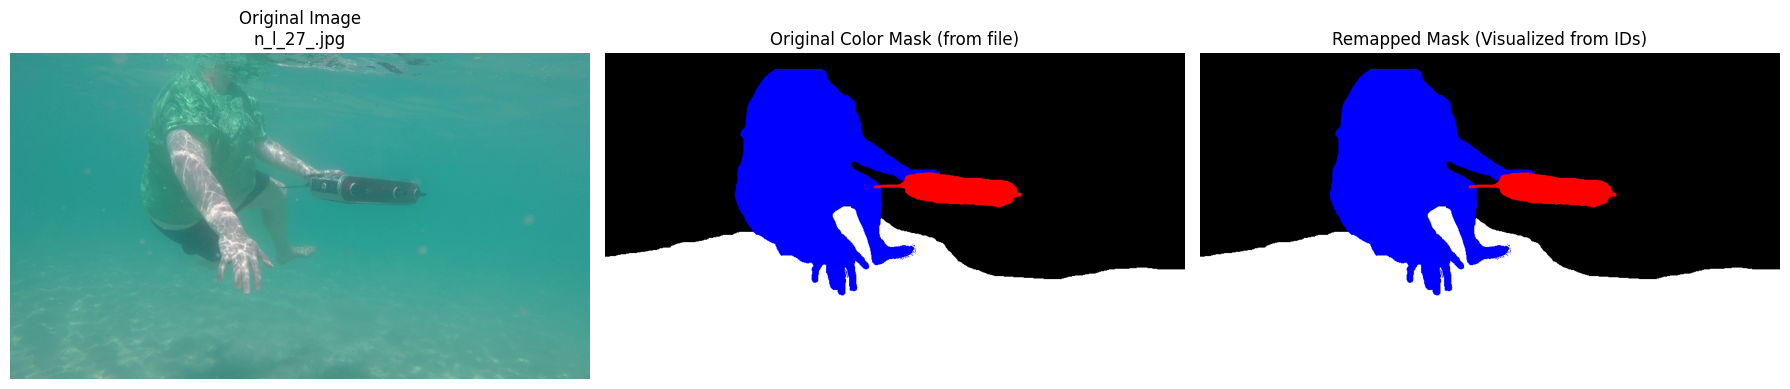


--- Verification Complete ---
If the 'Original Color Mask' and 'Remapped Mask (Visualized from IDs)' look identical for all displayed images,
then your mask loading and remapping logic is correct!


In [2]:
# --- Cell 1: Imports, Setup Paths, and Select Random Images ---
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random # New import for random selection

# IMPORTANT: Adjust this path to your dataset's root directory
data_root = './Dataset' 

# Define the split you want to test (e.g., 'train_val', 'test')
data_split = 'train_val' 

image_dir = os.path.join(data_root, data_split, 'images')
mask_dir = os.path.join(data_root, data_split, 'masks')

# Get a list of all image files in the directory
all_image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

if not all_image_files:
    print(f"Error: No image files found in {image_dir}. Please check the path and file extensions.")
else:
    # Choose how many random images you want to check
    num_images_to_check = 3 # You can change this number
    
    # Select random image names
    # Ensure num_images_to_check doesn't exceed the total number of available images
    if num_images_to_check > len(all_image_files):
        num_images_to_check = len(all_image_files)
        print(f"Warning: Reduced num_images_to_check to {num_images_to_check} as there are fewer images available.")

    selected_image_names = random.sample(all_image_files, num_images_to_check)

    print(f"Selected {num_images_to_check} random images for verification:")
    for img_name in selected_image_names:
        print(f"- {img_name}")

# --- Cell 2: Define Class Mappings (from configs/project_settings.py) ---

# The order here defines the integer ID. Background is typically 0.
# SUIM Dataset 8 Classes
# Class ID: (Class Name, RGB_Color_for_Visualization)

CLASS_MAPPING = {
    "Background waterbody": (0, [0, 0, 0]),           # Black (000)
    "Human divers": (1, [0, 0, 255]),                  # Blue (001)
    "Plants/sea-grass": (2, [0, 255, 0]),             # Green (010)
    "Wrecks/ruins": (3, [0, 255, 255]),                # Cyan (011)
    "Robots/instruments": (4, [255, 0, 0]),            # Red (100)
    "Reefs and invertebrates": (5, [255, 0, 255]),     # Magenta (101)
    "Fish and vertebrates": (6, [255, 255, 0]),        # Yellow (110)
    "Sand/sea-floor (& rocks)": (7, [255, 255, 255])   # White (111)
}

# Reverse mapping for quick lookup from ID to name
ID_TO_CLASS = {v[0]: k for k, v in CLASS_MAPPING.items()}

# Mapping from ID to visualization RGB color
ID_TO_COLOR = {v[0]: v[1] for k, v in CLASS_MAPPING.items()}

# Define a default color for unknown/unmapped labels, usually black (background)
UNKNOWN_COLOR = [0, 0, 0]

# --- Pre-process the CLASS_MAPPING for efficient RGB_to_ID lookup ---
# This creates a dictionary mapping (R, G, B) tuples to their corresponding Class IDs (0-7)
RGB_TO_CLASS_ID = {tuple(v[1]): v[0] for v in CLASS_MAPPING.values()}

# Define a default background ID and its color for initialization
DEFAULT_BACKGROUND_ID = 0 
DEFAULT_BACKGROUND_RGB = tuple([0, 0, 0]) 

print("Class mappings loaded successfully.")
print(f"Example RGB_TO_CLASS_ID: {list(RGB_TO_CLASS_ID.items())[0]} and {list(RGB_TO_CLASS_ID.items())[1]}")

# --- Cell 3: Define Visualization Function (to be called for each image) ---

def visualize_mask_as_rgb(mask_id_array, id_to_color_map):
    """
    Converts a single-channel mask of integer class IDs back into a colorful RGB image
    for visualization, using the provided ID-to-Color mapping.
    """
    h, w = mask_id_array.shape
    colored_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_id, color_rgb in id_to_color_map.items():
        colored_mask[mask_id_array == class_id] = color_rgb
        
    return colored_mask,color_rgb

print("Visualization function defined.")

# --- Cell 4: Loop Through Selected Images and Perform Verification ---

if 'selected_image_names' in locals() and selected_image_names:
    for i, img_name in enumerate(selected_image_names):
        print(f"\n--- Processing Image {i+1}/{len(selected_image_names)}: {img_name} ---")
        
        base_name = os.path.splitext(img_name)[0]
        mask_name = base_name + '.bmp' 
        
        image_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Error: Could not load image: {image_path}. Skipping.")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask as color image
        mask_color = cv2.imread(mask_path, cv2.IMREAD_COLOR) 
        if mask_color is None:
            print(f"Error: Could not load mask: {mask_path}. Skipping.")
            continue
        mask_color = cv2.cvtColor(mask_color, cv2.COLOR_BGR2RGB)

        # Check and resize mask if dimensions differ
        if image.shape[:2] != mask_color.shape[:2]:
            print(f"Warning: Image and mask dimensions differ for {img_name}. Resizing mask from {mask_color.shape[:2]} to {image.shape[:2]}")
            mask_color = cv2.resize(mask_color, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Create remapped mask_id
        mask_id = np.full(mask_color.shape[:2], fill_value=DEFAULT_BACKGROUND_ID, dtype=np.uint8) 
        for rgb_color_tuple, class_id_int in RGB_TO_CLASS_ID.items():
            mask_id[np.all(mask_color == np.array(rgb_color_tuple), axis=2)] = class_id_int

        # Print debug info
        print(f"  Remapped Class ID Mask shape: {mask_id.shape}")
        print(f"  Unique pixel values in remapped mask_id (should be 0-7): {np.unique(mask_id)}")
        unique_rgb_colors_in_mask = np.unique(mask_color.reshape(-1, mask_color.shape[2]), axis=0)
        print(f"  Unique RGB colors found in original mask: {unique_rgb_colors_in_mask}")
        
        # Verify if these unique colors are all present in your CLASS_MAPPING
        unmapped_colors = []
        for rgb_val in unique_rgb_colors_in_mask:
            if tuple(rgb_val) not in RGB_TO_CLASS_ID:
                unmapped_colors.append(rgb_val)
        if unmapped_colors:
            print(f"  Warning: Unmapped RGB colors found in mask: {unmapped_colors}. These pixels will be mapped to default background ({DEFAULT_BACKGROUND_ID}).")


        # Convert the remapped mask_id back to a visual RGB mask
        remapped_mask_visual,_ = visualize_mask_as_rgb(mask_id, ID_TO_COLOR)

        # Display side-by-side comparison
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title(f"Original Image\n{img_name}")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(mask_color)
        plt.title("Original Color Mask (from file)")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(remapped_mask_visual)
        plt.title("Remapped Mask (Visualized from IDs)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    print("\n--- Verification Complete ---")
    print("If the 'Original Color Mask' and 'Remapped Mask (Visualized from IDs)' look identical for all displayed images,")
    print("then your mask loading and remapping logic is correct!")
else:
    print("No images selected or found to perform verification.")